# Assignment 1: Mapping vegetation in your city
Zhanchao Yang

Instruction:
1. Collect the city limit file for the city (hint: reproject it into wgs 84 projection, epsg code of 4326 using QGIS).
2. Download the NAIP tiles and mosaic them.
3. Mask out those pixels outside the bounds.
4. Calculate the NDVI and vegetation cover map (hint: you can use a threshold of 0.1 to separate vegetation and non-vegetation based on NDVI). 
5. Generate the census tract-level map of NDVI and vegetation cover (hint: make sure the projection of the shapefile and raster matched; reproject the shapefile to the same projection as your raster data, because it is easier to reproject a shapefile)

**City**: Las Vegas, NV

In [1]:
import os
import glob
import urllib.request

import numpy as np
import pandas as pd
import geopandas as gpd

import rasterio as rio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.features import geometry_mask
from rasterio.windows import Window
from rasterstats import zonal_stats

import pystac_client
import planetary_computer as pc
from shapely.geometry import box, shape, mapping

import matplotlib.pyplot as plt

from pygris import tracts

from shapely.geometry import box, mapping

## 1. City boundary

The city limit comes from the City of Las Vegas open data portal. STAC searches are always in
lon/lat, so the first thing to do is put the layer in EPSG:4326.

In [2]:
boundary = gpd.read_file("data/City_Limits_LV.geojson").to_crs(epsg=4326)

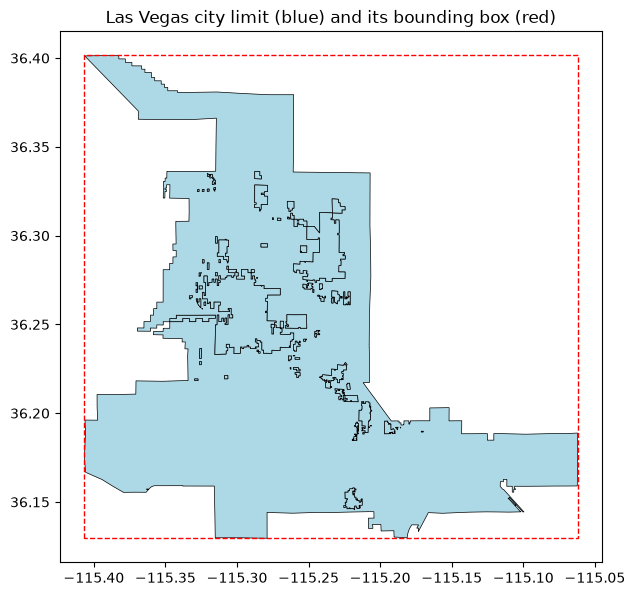

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
boundary.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)
gpd.GeoSeries([box(*boundary.total_bounds)], crs='EPSG:4326').boundary.plot(
    ax=ax, color='red', linestyle='--', linewidth=1)
ax.set_title('Las Vegas city limit (blue) and its bounding box (red)')
plt.show()

## 2. Download the NAIP tiles

In [4]:
boundary_bounds = boundary.total_bounds

In [5]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

In [6]:
start_date = "2022-01-01"
end_date = "2022-12-31"

search = catalog.search(
    collections=["naip"],
    intersects=mapping(box(*boundary.total_bounds)),
    datetime=f"{start_date}/{end_date}",
)

items = search.item_collection()

print(len(items))

35


In [7]:
parts = list(boundary.geometry)

keep = []

for item in items:
    tile_geometry = shape(item.geometry)

    if any(tile_geometry.intersects(part) for part in parts):
        keep.append(item)

print(f"{len(items)} tiles in bounding box")
print(f"{len(keep)} tiles intersect boundary")

35 tiles in bounding box
24 tiles intersect boundary


In [8]:
paths = []

outfolder = "data/naip"

In [9]:
for n, item in enumerate(keep, start=1):
    outfile = os.path.join(
        outfolder,
        item.id + ".tif"
    )

    if os.path.exists(outfile):
        print(f"[{n}/{len(keep)}] already exists: {item.id}")
    else:
        print(f"[{n}/{len(keep)}] downloading: {item.id}")
        urllib.request.urlretrieve(
            item.assets["image"].href,
            outfile
        )
        
    paths.append(outfile)

[1/24] already exists: nv_m_3611545_ne_11_060_20220704
[2/24] already exists: nv_m_3611537_se_11_060_20220704
[3/24] already exists: nv_m_3611547_nw_11_060_20220703
[4/24] already exists: nv_m_3611546_nw_11_060_20220703
[5/24] already exists: nv_m_3611546_ne_11_060_20220703
[6/24] already exists: nv_m_3611538_sw_11_060_20220703
[7/24] already exists: nv_m_3611538_se_11_060_20220703
[8/24] already exists: nv_m_3611556_sw_11_060_20220611
[9/24] already exists: nv_m_3611556_nw_11_060_20220611
[10/24] already exists: nv_m_3611556_ne_11_060_20220611
[11/24] already exists: nv_m_3611555_sw_11_060_20220611
[12/24] already exists: nv_m_3611555_se_11_060_20220611
[13/24] already exists: nv_m_3611555_nw_11_060_20220611
[14/24] already exists: nv_m_3611555_ne_11_060_20220611
[15/24] already exists: nv_m_3611554_sw_11_060_20220611
[16/24] already exists: nv_m_3611554_se_11_060_20220611
[17/24] already exists: nv_m_3611554_nw_11_060_20220611
[18/24] already exists: nv_m_3611554_ne_11_060_20220611
[

## 3. Mosaic the tiles

In [10]:
datasets = [rio.open(path) for path in paths]

# reduce resolution by factor of 10

dsfactor = 10

xres = datasets[0].res[0] * dsfactor

yres = datasets[0].res[1] * dsfactor

# mosaic + resample

mosaic, transform = merge(

    datasets,

    res=(xres, yres)

)

print(mosaic.shape)

(4, 5877, 6707)


In [11]:
red   = mosaic[0]
green = mosaic[1]
blue  = mosaic[2]
nir   = mosaic[3]

In [12]:
rgb = np.dstack([red, green, blue])

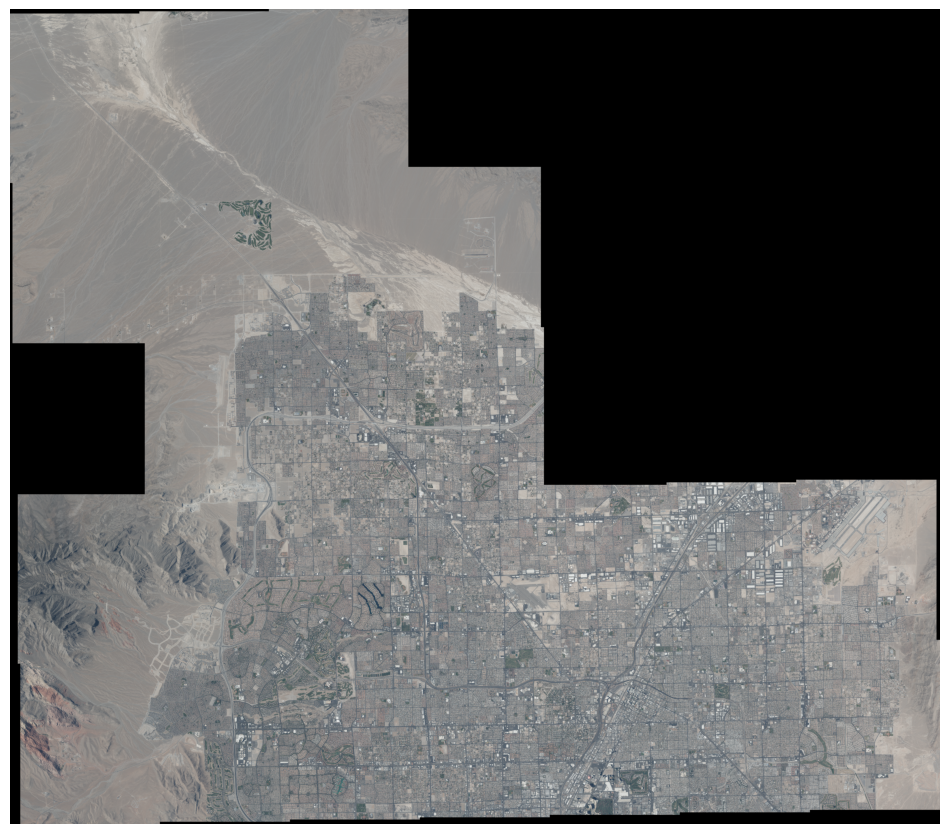

In [13]:
plt.figure(figsize=(12, 12))
plt.imshow(rgb)
plt.axis("off")
plt.show()

## 4. Mask to the city limit

In [14]:
boundary_reprojected = boundary.to_crs(datasets[0].crs)

In [15]:
masked = geometry_mask(
    boundary_reprojected.geometry,
    out_shape=(mosaic.shape[1], mosaic.shape[2]),
    transform=transform,
    invert=True
)

In [16]:
mosaic_city = np.where(masked[None, :, :], mosaic, 0)

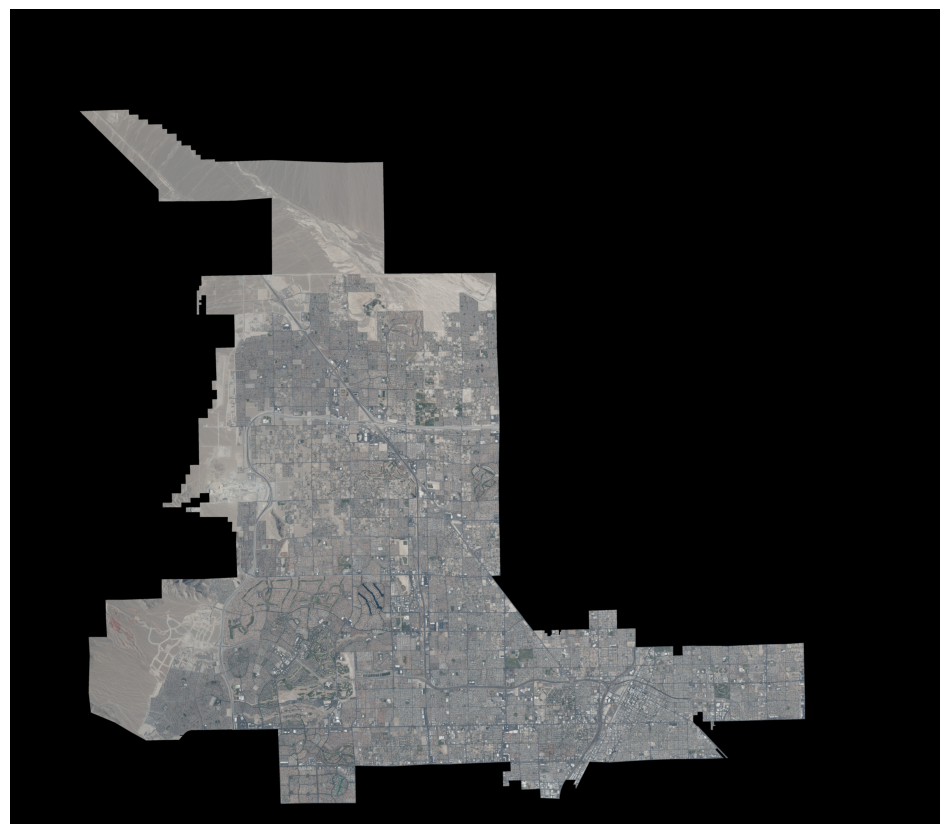

In [17]:
rgb = np.dstack([
    mosaic_city[0],
    mosaic_city[1],
    mosaic_city[2]
])

plt.figure(figsize=(12, 12))
plt.imshow(rgb)
plt.axis("off")
plt.show()

## 5. Compute NDVI and vegetation cover

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

In [18]:
red = mosaic_city[0].astype("float32")
nir = mosaic_city[3].astype("float32")

ndvi = (nir - red) / (nir + red + 1e-6)

In [19]:
ndvi[~masked] = np.nan

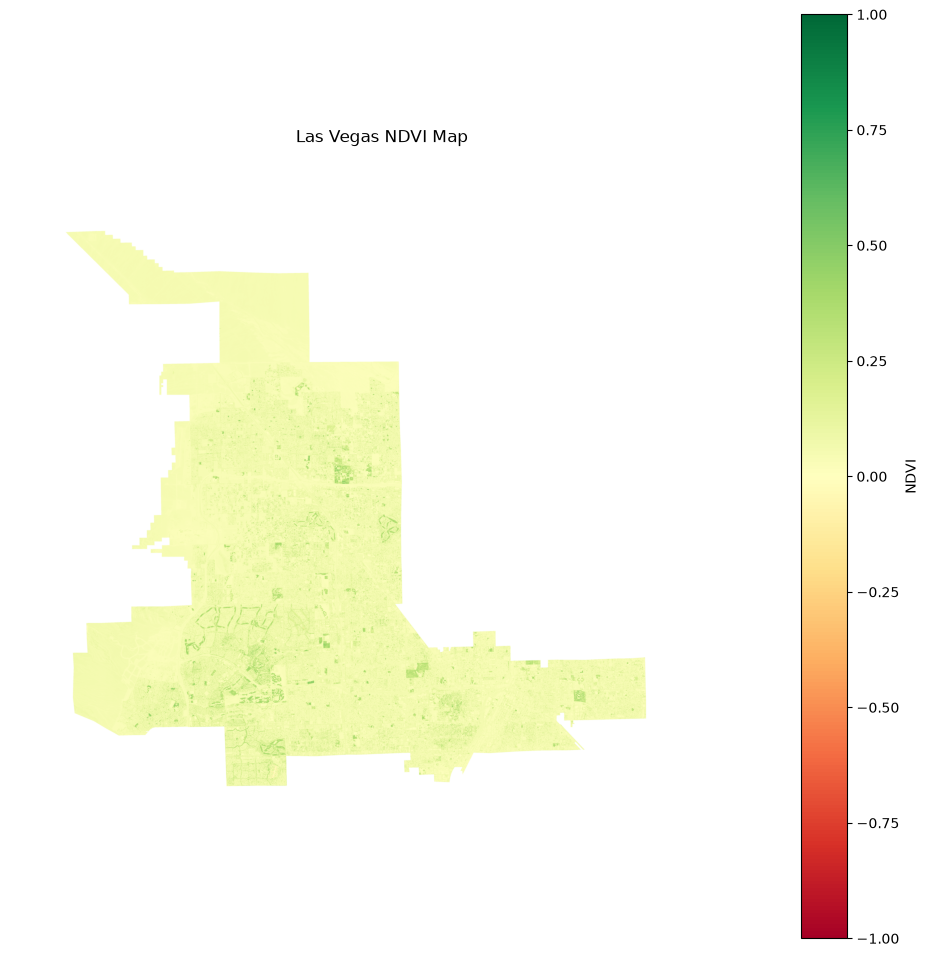

In [43]:
plt.figure(figsize=(12, 12))
plt.imshow(ndvi, vmin=-1, vmax=1, cmap="RdYlGn")
plt.title("Las Vegas NDVI Map")
plt.colorbar(label="NDVI")
plt.axis("off")
plt.show()

In [21]:
vegetation = ndvi > 0.1

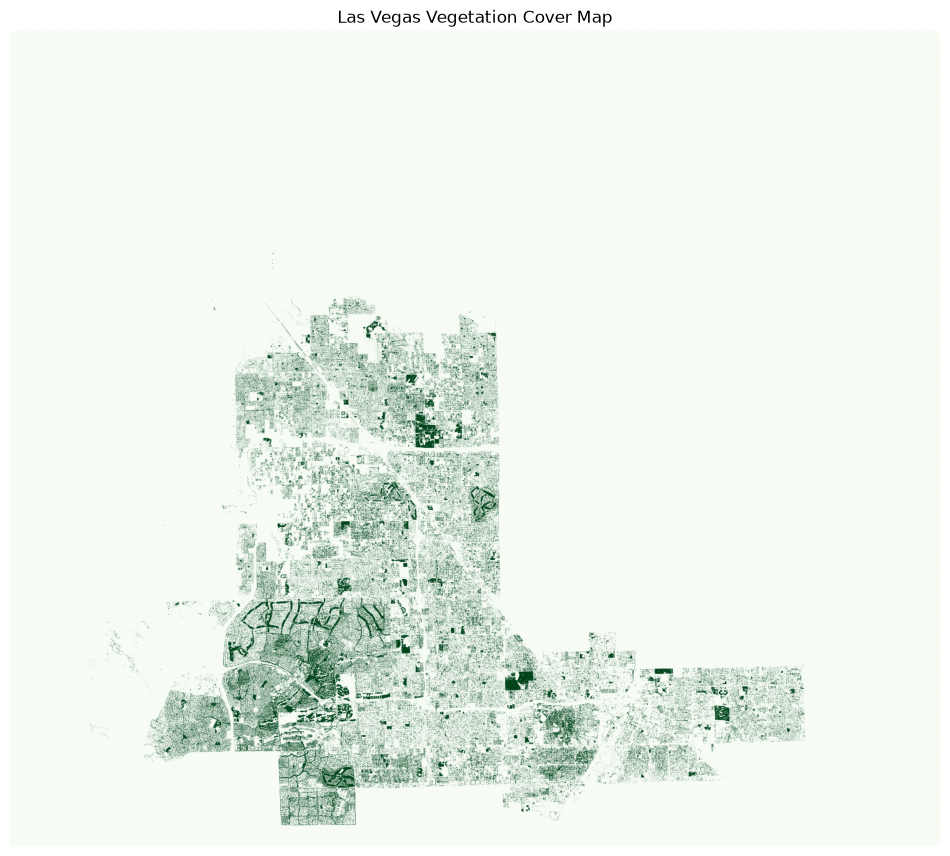

In [42]:
plt.figure(figsize=(12, 12))
plt.imshow(vegetation, cmap="Greens")
plt.title("Las Vegas Vegetation Cover Map")
plt.axis("off")
plt.show()

In [23]:
vegetation_cover = vegetation[masked].mean() * 100

print(f"Vegetation cover: {vegetation_cover:.2f}%")

Vegetation cover: 16.83%


## 5. Census tract-level NDVI and vegetation cover


In [24]:
tracts_gdf = tracts(
    state="NV",
    county="Clark",
    year=2023
)

Using FIPS code '32' for input 'NV'
Using FIPS code '003' for input 'Clark'


In [25]:
tracts_gdf = tracts_gdf.to_crs(datasets[0].crs)

In [34]:
tracts_city = gpd.clip(
    tracts_gdf,
    boundary_reprojected
)

In [35]:
ndvi_stats = zonal_stats(
    tracts_city,
    ndvi,
    affine=transform,
    stats=["mean"],
    nodata=np.nan
)

tracts_city["mean_ndvi"] = [
    x["mean"] for x in ndvi_stats
]

In [36]:
veg_float = vegetation.astype("float32")
veg_float[~masked] = np.nan

In [37]:
veg_stats = zonal_stats(
    tracts_city,
    veg_float,
    affine=transform,
    stats=["mean"],
    nodata=np.nan
)

tracts_city["veg_cover"] = [
    x["mean"] * 100 if x["mean"] is not None else np.nan
    for x in veg_stats
]

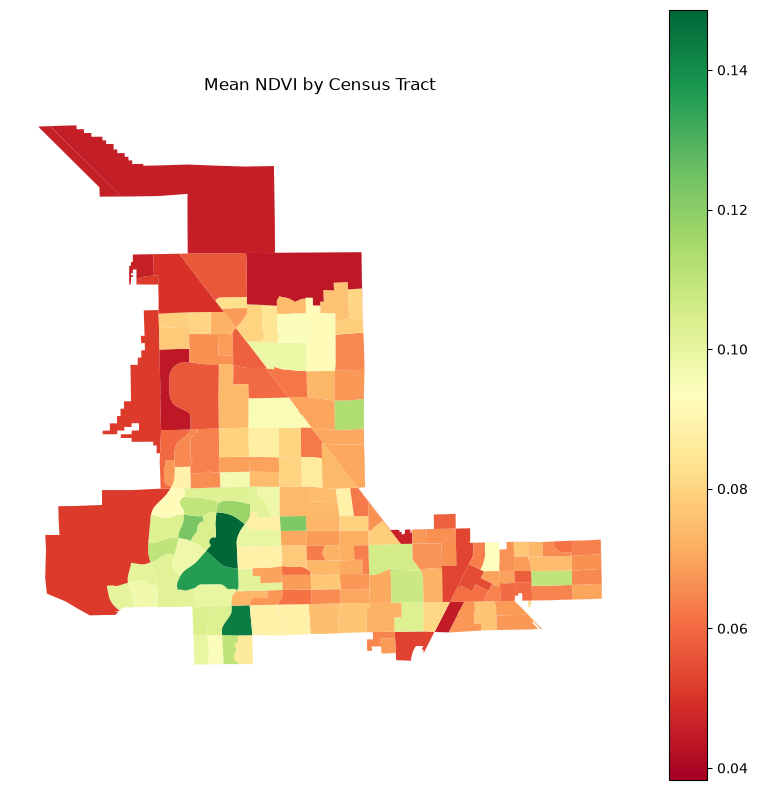

In [40]:
ax = tracts_city.plot(
    column="mean_ndvi",
    figsize=(10, 10),
    legend=True,
    cmap="RdYlGn"
)

ax.set_title("Mean NDVI by Census Tract")
ax.set_axis_off()

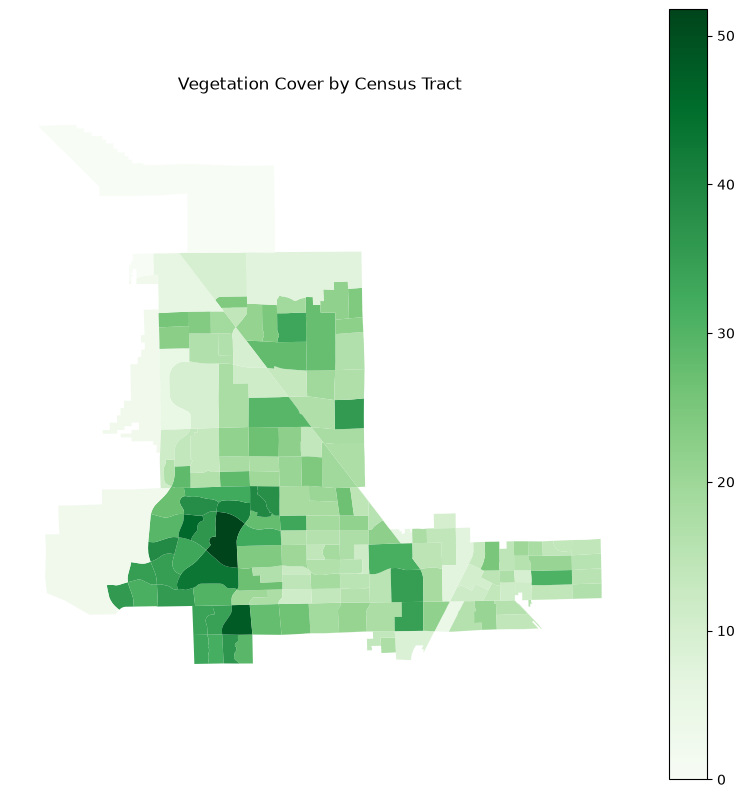

In [41]:
ax = tracts_city.plot(
    column="veg_cover",
    figsize=(10, 10),
    legend=True,
    cmap="Greens"
)

ax.set_title("Vegetation Cover by Census Tract")
ax.set_axis_off()